<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/3-calculus-i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculus I: Limits & Derivatives

This topic, *Calculus I: Limits & Derivatives*, introduces the mathematical field of calculus -- the study of rates of change -- from the ground up. It is essential because computing derivatives via differentiation is the basis of optimizing most machine learning algorithms, including those used in deep learning such as backpropagation and stochastic gradient descent. 

Through the measured exposition of theory paired with interactive examples, you’ll develop a working understanding of how calculus is used to compute limits and differentiate functions. You’ll also learn how to apply automatic differentiation within the popular TensorFlow 2 and PyTorch machine learning libraries. The content covered in this class is itself foundational for several other topics in the *Machine Learning Foundations* series, especially *Calculus II* and *Optimization*.

Over the course of studying this topic, you'll: 

* Develop an understanding of what’s going on beneath the hood of machine learning algorithms, including those used for deep learning. 
* Be able to more intimately grasp the details of machine learning papers as well as many of the other subjects that underlie ML, including partial-derivative calculus, statistics and optimization algorithms. 
* Compute the derivatives of functions, including by using AutoDiff in the popular TensorFlow 2 and PyTorch libraries.

**Note that this Jupyter notebook is not intended to stand alone. It is the companion code to a lecture or to videos from Jon Krohn's [Machine Learning Foundations](https://github.com/jonkrohn/ML-foundations) series, which offer detail on the following:**

*Segment 1: Limits*

* What Calculus Is
* A Brief History of Calculus
* The Method of Exhaustion 
* Calculating Limits 

*Segment 2: Computing Derivatives with Differentiation*
* The Delta Method
* The Differentiation Equation
* Derivative Notation
* The Power Rule
* The Constant Multiple Rule
* The Sum Rule
* The Product Rule
* The Quotient Rule
* The Chain Rule

*Segment 3: Automatic Differentiation*
* AutoDiff with PyTorch
* AutoDiff with TensorFlow 2
* Machine Learning via Differentiation 
* Cost (or Loss) Functions
* The Future: Differentiable Programming 


## Calculus

Calculus is the mathematical study of continuous change.



Calculus is the branch of mathematics that studies how quantities change, using the ideas of limits, derivatives, and integrals. Its two main branches are differential calculus, which focuses on rates of change and slopes, and integral calculus, which focuses on accumulation and areas under curves.



### Differential Calculus

Consider a vehicle starting from home at time $t = 0$ minutes and distance $d = 0$ km. It first accelerates for 5 minutes, then stops for 5 minutes (distance stays constant), and finally moves away from home at a constant speed. On a distance–time graph, the slope of the tangent line at any point gives the instantaneous speed, and comparing slopes across time helps us reason about acceleration.


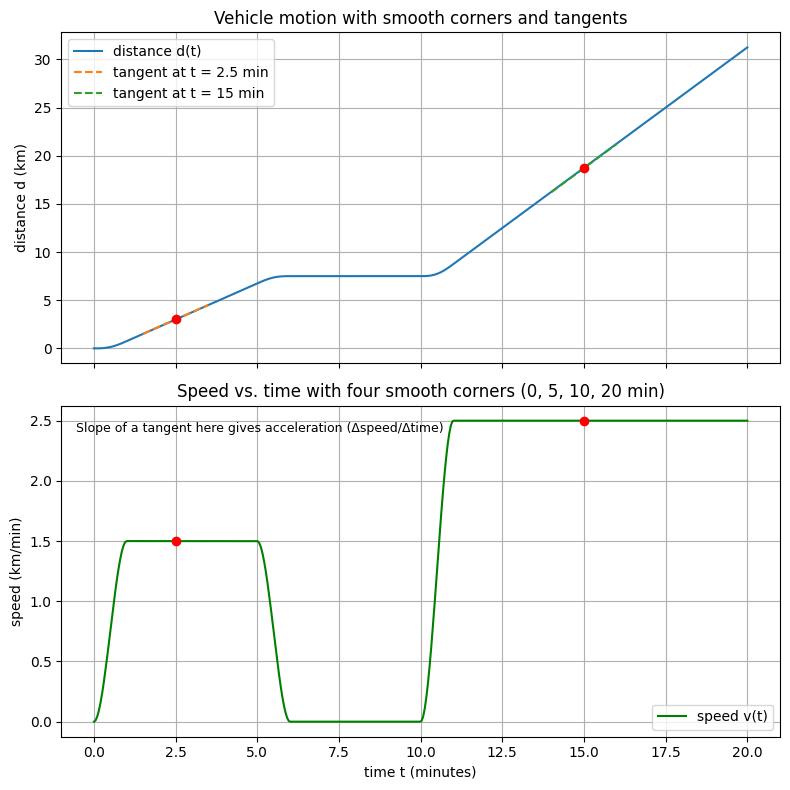

In [91]:
# Distance–time graph with smooth corners and tangent lines,

# plus a speed–time graph with four smooth corners

import numpy as np

import matplotlib.pyplot as plt



# Time in minutes

t = np.linspace(0, 20, 400)



# Smooth step function for rounded "corners"

def smoothstep(s):

    s = np.clip(s, 0, 1)

    return 3 * s**2 - 2 * s**3



# Parameters for motion

tau = 1.0       # width of each smooth transition (in minutes)

v1 = 1.5        # cruising speed during first motion phase (km/min)

v2 = 2.5        # cruising speed during final phase (km/min)



# Build speed profile v(t) with exactly four smooth transitions

#   0–5 min: move at speed ~v1

#   5–10 min: stop (speed ~0)

#   10–20 min: move at speed ~v2

# Transitions (rounded corners) occur near t = 0, 5, 10, 20.

s0  = smoothstep((t - 0)  / tau)

s5  = smoothstep((t - 5)  / tau)

s10 = smoothstep((t - 10) / tau)

s20 = smoothstep((t - 20) / tau)


# Smooth "box" for each cruising interval

v = v1 * (s0 - s5) + v2 * (s10 - s20)


# Distance d(t) obtained by integrating speed

d = np.zeros_like(t)

dt = np.diff(t)

d[1:] = np.cumsum(0.5 * (v[1:] + v[:-1]) * dt)


# Here, speed is exactly the slope of the distance–time graph

slopes = v


# Choose times where we draw tangents (one point each)

t1 = 2.5   # during first motion phase

t2 = 15.0  # during final motion phase


idx1 = np.argmin(np.abs(t - t1))

idx2 = np.argmin(np.abs(t - t2))


d1 = d[idx1]

d2 = d[idx2]

m1 = slopes[idx1]

m2 = slopes[idx2]


# Local windows for tangent line segments

t1_window = np.linspace(t1 - 1, t1 + 1, 100)

t2_window = np.linspace(t2 - 1, t2 + 1, 100)


tan1 = d1 + m1 * (t1_window - t1)

tan2 = d2 + m2 * (t2_window - t2)


# Create two subplots: distance–time and speed–time

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)


# Top: distance–time with tangent lines

ax1.plot(t, d, label="distance d(t)")

ax1.plot(t1_window, tan1, "--", label="tangent at t = 2.5 min")

ax1.plot(t2_window, tan2, "--", label="tangent at t = 15 min")

ax1.scatter([t1, t2], [d1, d2], color="red", zorder=3)

ax1.set_ylabel("distance d (km)")

ax1.set_title("Vehicle motion with smooth corners and tangents")

ax1.legend()

ax1.grid(True)


# Bottom: speed–time (slope of the distance–time graph)

ax2.plot(t, slopes, color="green", label="speed v(t)")

ax2.scatter([t1, t2], [m1, m2], color="red", zorder=3)

ax2.set_xlabel("time t (minutes)")

ax2.set_ylabel("speed (km/min)")

ax2.set_title("Speed vs. time with four smooth corners (0, 5, 10, 20 min)")

# Note: On this speed–time graph, the slope of a tangent line at a point

# gives the instantaneous acceleration (change in speed per minute).

ax2.text(0.02, 0.95, "Slope of a tangent here gives acceleration (Δspeed/Δtime)",

         transform=ax2.transAxes, va="top", fontsize=9)

ax2.legend()

ax2.grid(True)


plt.tight_layout()

plt.show()

### Integral Calculus


Integral calculus is concerned with accumulation. One of the most important ideas is that the area under a curve represents a total accumulated quantity over an interval.


For example, the area under a speed–time graph over a period of time gives the total distance traveled during that period. In the next cell, we shade the area under the same speed–time curve from the previous section and interpret what it means.

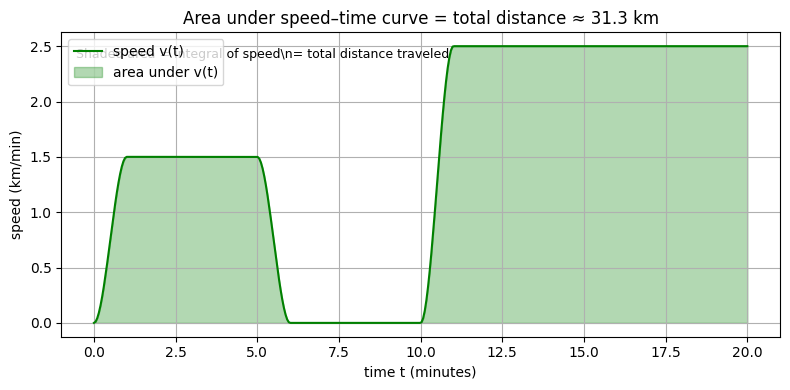

In [92]:
import numpy as np
import matplotlib.pyplot as plt


# Time in minutes
t = np.linspace(0, 20, 400)

# Smooth step function (same shape as before)
def smoothstep(s):
    s = np.clip(s, 0, 1)
    return 3 * s**2 - 2 * s**3

# Parameters for the speed profile (same as earlier example)
tau = 1.0       # width of smooth transitions (minutes)
v1 = 1.5        # speed during first motion phase (km/min)
v2 = 2.5        # speed during final motion phase (km/min)

s0  = smoothstep((t - 0)  / tau)
s5  = smoothstep((t - 5)  / tau)
s10 = smoothstep((t - 10) / tau)
s20 = smoothstep((t - 20) / tau)

# Speed v(t): move, stop, then move faster, with four smooth corners
v = v1 * (s0 - s5) + v2 * (s10 - s20)

# Approximate total distance as the area under the speed–time curve (integral)
distance_total = np.trapz(v, t)

fig, ax = plt.subplots(figsize=(8, 4))

# Plot speed–time curve
ax.plot(t, v, color="green", label="speed v(t)")

# Shade the area under the curve down to the time axis
ax.fill_between(t, v, 0, color="green", alpha=0.3, label="area under v(t)")

ax.set_xlabel("time t (minutes)")
ax.set_ylabel("speed (km/min)")
ax.set_title(f"Area under speed–time curve = total distance ≈ {distance_total:.1f} km")

# This shaded area is the integral of speed over time,
ax.text(0.02, 0.95,
        "Shaded area = integral of speed\\n= total distance traveled",
        transform=ax.transAxes, va="top", fontsize=9)

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

### The moethod of exhausion:
The method of exhaustion is an ancient geometric technique that finds areas or volumes by bounding a shape with simpler known shapes (inside and outside) and refining those bounds until the gap is exhausted (approaches zero). It is an early form of limit-based reasoning. Also called Calculus of infinitesimals.

## Modern Calculus Applications


- Differentials: Helps to find minima and maxima of a curve
    - Used in ML including deep learning

        - Gradient descent to minimize cost

        - Gradient ascent to maximize reward

    - Higher-order derivatives used in "fancy" optimizer (Optimizer): It would be higher order derivatives of a gradient. It shows how quickly an algorithm is learning

- Integrals: Find area under curve:
    - Receiver operating characteristics (Calc II) i.e in binary classification it would be a step graph and the area under the graph shows false positive (i.e is this a car?)
    
    - Probability theory's "expectation" of random variable is widely used in ML including deep learning (prob. & info. thy)




Below, we visualize a simple example of gradient descent minimizing a quadratic cost function, and show how the derivative (slope) guides each update step toward the minimum.

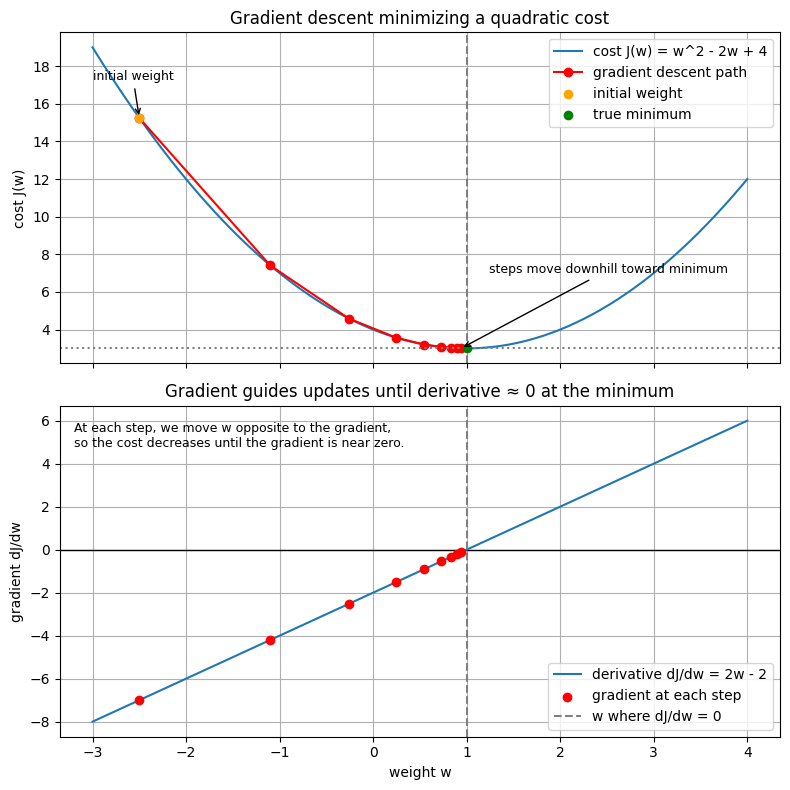

In [93]:
import numpy as np
import matplotlib.pyplot as plt


# Quadratic cost function and its derivative (gradient)
def cost(w):
    return w**2 - 2*w + 4  # J(w) = w^2 - 2w + 4

def grad(w):
    return 2*w - 2          # dJ/dw = 2w - 2


# Gradient descent parameters
w0 = -2.5          # initial weight (starting point)
learning_rate = 0.2
num_steps = 8


# Run gradient descent and record the path
w_history = [w0]
J_history = [cost(w0)]
for step in range(num_steps):
    g = grad(w_history[-1])
    new_w = w_history[-1] - learning_rate * g  # move opposite the gradient
    w_history.append(new_w)
    J_history.append(cost(new_w))

w_history = np.array(w_history)
J_history = np.array(J_history)

# True analytic minimum of J(w) = w^2 - 2w + 4
w_star = 1.0
J_star = cost(w_star)

# Smooth curves for plotting
w_vals = np.linspace(-3, 4, 400)
J_vals = cost(w_vals)
g_vals = grad(w_vals)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Top: Cost curve J(w) with gradient descent steps
ax1.plot(w_vals, J_vals, label="cost J(w) = w^2 - 2w + 4")
ax1.plot(w_history, J_history, "o-", color="red", label="gradient descent path")
ax1.scatter([w0], [cost(w0)], color="orange", zorder=3, label="initial weight")
ax1.scatter([w_star], [J_star], color="green", zorder=3, label="true minimum")
ax1.axvline(w_star, color="gray", linestyle="--")
ax1.axhline(J_star, color="gray", linestyle=":")
ax1.set_ylabel("cost J(w)")
ax1.set_title("Gradient descent minimizing a quadratic cost")
ax1.grid(True)
ax1.legend()

# Annotate start and near-final point
ax1.annotate("initial weight", xy=(w_history[0], J_history[0]),
             xytext=(w_history[0]-0.5, J_history[0]+2),
             arrowprops=dict(arrowstyle="->"), fontsize=9)
ax1.annotate("steps move downhill toward minimum",
             xy=(w_history[-1], J_history[-1]),
             xytext=(w_history[-1]+0.3, J_history[-1]+4),
             arrowprops=dict(arrowstyle="->"), fontsize=9)

# Bottom: Derivative (gradient) curve dJ/dw with samples at each step
ax2.axhline(0, color="black", linewidth=1)
ax2.plot(w_vals, g_vals, label="derivative dJ/dw = 2w - 2")
ax2.scatter(w_history, grad(w_history), color="red", zorder=3, label="gradient at each step")
ax2.axvline(w_star, color="gray", linestyle="--", label="w where dJ/dw = 0")
ax2.set_xlabel("weight w")
ax2.set_ylabel("gradient dJ/dw")
ax2.set_title("Gradient guides updates until derivative ≈ 0 at the minimum")
ax2.grid(True)
ax2.legend()

# Explanatory note
ax2.text(0.02, 0.95, "At each step, we move w opposite to the gradient,\nso the cost decreases until the gradient is near zero.",
         transform=ax2.transAxes, va="top", fontsize=9)

plt.tight_layout()
plt.show()

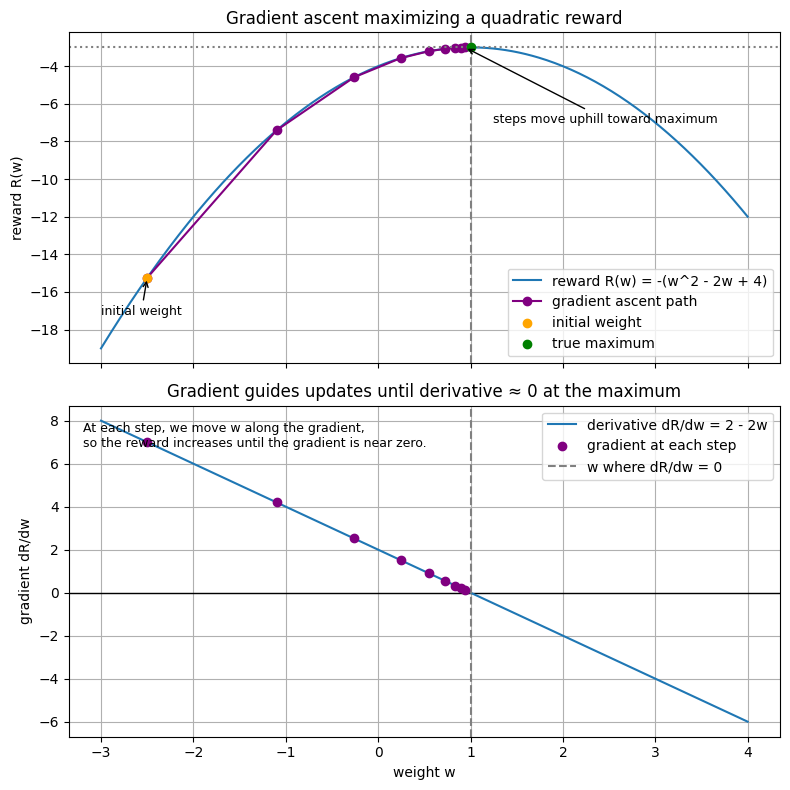

In [94]:
import numpy as np
import matplotlib.pyplot as plt


# Quadratic reward function and its derivative (gradient) for ascent
def reward(w):
    # Reward is the negative of the previous cost: maximize instead of minimize
    return -(w**2 - 2*w + 4)  # R(w) = -(w^2 - 2w + 4)

def grad_reward(w):
    return -(2*w - 2)         # dR/dw = -(2w - 2) = 2 - 2w


# Gradient ascent parameters
w0 = -2.5          # initial weight (starting point)
learning_rate = 0.2
num_steps = 8


# Run gradient ascent and record the path
w_history = [w0]
R_history = [reward(w0)]
for step in range(num_steps):
    g = grad_reward(w_history[-1])
    new_w = w_history[-1] + learning_rate * g  # move in the direction of the gradient
    w_history.append(new_w)
    R_history.append(reward(new_w))

w_history = np.array(w_history)
R_history = np.array(R_history)

# True analytic maximum of R(w) = -(w^2 - 2w + 4)
w_star = 1.0
R_star = reward(w_star)

# Smooth curves for plotting
w_vals = np.linspace(-3, 4, 400)
R_vals = reward(w_vals)
g_vals = grad_reward(w_vals)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Top: Reward curve R(w) with gradient ascent steps
ax1.plot(w_vals, R_vals, label="reward R(w) = -(w^2 - 2w + 4)")
ax1.plot(w_history, R_history, "o-", color="purple", label="gradient ascent path")
ax1.scatter([w0], [reward(w0)], color="orange", zorder=3, label="initial weight")
ax1.scatter([w_star], [R_star], color="green", zorder=3, label="true maximum")
ax1.axvline(w_star, color="gray", linestyle="--")
ax1.axhline(R_star, color="gray", linestyle=":")
ax1.set_ylabel("reward R(w)")
ax1.set_title("Gradient ascent maximizing a quadratic reward")
ax1.grid(True)
ax1.legend()

# Annotate start and near-final point
ax1.annotate("initial weight", xy=(w_history[0], R_history[0]),
             xytext=(w_history[0]-0.5, R_history[0]-2),
             arrowprops=dict(arrowstyle="->"), fontsize=9)
ax1.annotate("steps move uphill toward maximum",
             xy=(w_history[-1], R_history[-1]),
             xytext=(w_history[-1]+0.3, R_history[-1]-4),
             arrowprops=dict(arrowstyle="->"), fontsize=9)

# Bottom: Derivative (gradient) curve dR/dw with samples at each step
ax2.axhline(0, color="black", linewidth=1)
ax2.plot(w_vals, g_vals, label="derivative dR/dw = 2 - 2w")
ax2.scatter(w_history, grad_reward(w_history), color="purple", zorder=3, label="gradient at each step")
ax2.axvline(w_star, color="gray", linestyle="--", label="w where dR/dw = 0")
ax2.set_xlabel("weight w")
ax2.set_ylabel("gradient dR/dw")
ax2.set_title("Gradient guides updates until derivative ≈ 0 at the maximum")
ax2.grid(True)
ax2.legend()

# Explanatory note
ax2.text(0.02, 0.95, "At each step, we move w along the gradient,\nso the reward increases until the gradient is near zero.",
         transform=ax2.transAxes, va="top", fontsize=9)

plt.tight_layout()
plt.show()

## Segment 1: Limits

### The Calculus of Infinitesimals
We zoon in into the parabolic graph till we reach a straight line.

In [95]:
import numpy as np
import matplotlib.pyplot as plt

In [185]:
x = np.linspace(-10, 10, 10000) # start, finish, n points

If $y = x^2 + 2x + 2$: 

In [188]:
y = x**2 + 2*x + 2

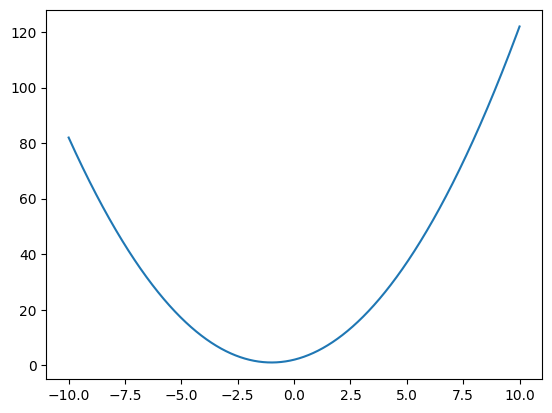

In [98]:
fig, ax = plt.subplots()
_ = ax.plot(x,y)

* There are no straight lines on the curve. 
* If we zoom in _infinitely_ close, however, we observe curves that _approach_ lines. 
* This enables us to find a slope $m$ (tangent) anywhere on the curve, including to identify where $m = 0$: 

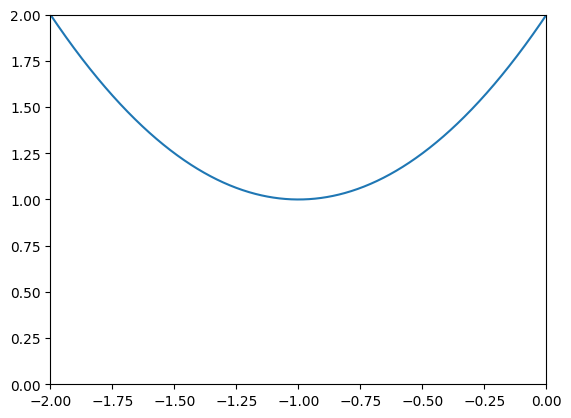

In [99]:
fig, ax = plt.subplots()
ax.set_xlim([-2, -0])
ax.set_ylim([0, 2])
_ = ax.plot(x,y)

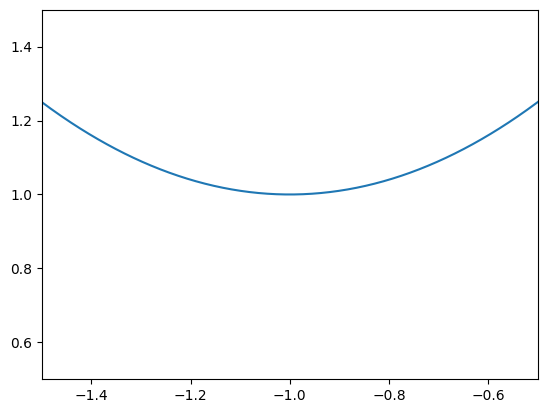

In [100]:
fig, ax = plt.subplots()
ax.set_xlim([-1.5, -0.5])
ax.set_ylim([0.5, 1.5])
_ = ax.plot(x,y)

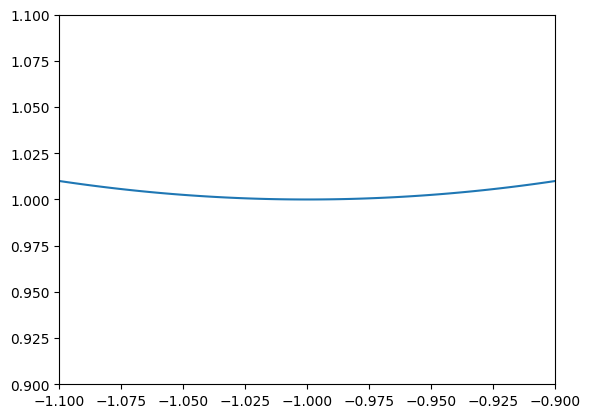

In [101]:
fig, ax = plt.subplots()
ax.set_xlim([-1.1, -0.9])
ax.set_ylim([0.9, 1.1])
_ = ax.plot(x,y)

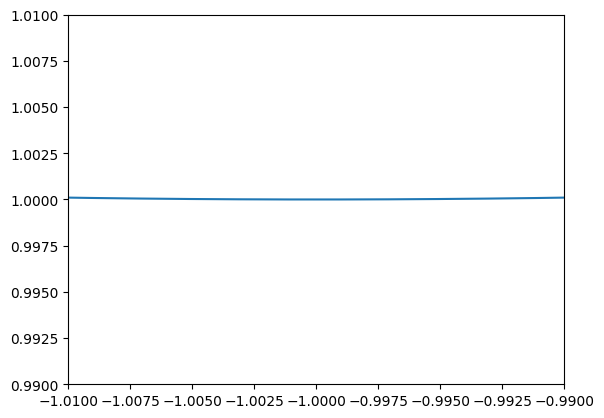

In [102]:
fig, ax = plt.subplots()
ax.set_xlim([-1.01, -0.99])
ax.set_ylim([0.99, 1.01])
_ = ax.plot(x,y)

**Return to slides here.**

### Limits
What is the limit as x approaches 5 in the expression $x^2 + 2x + 2$.
$$
\lim_{x \to 5} \left( x^2 + 2x + 2 \right)
$$

For a continuous function like this, we just substitute 5 for x.


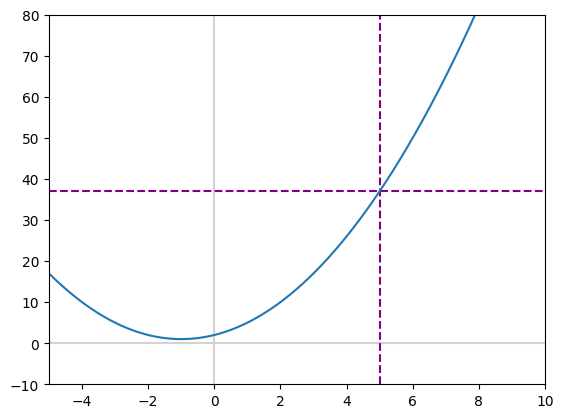

In [103]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-5, 10)
plt.ylim(-10, 80)
plt.axvline(x=5, color='purple', linestyle='--')
plt.axhline(y=37, color='purple', linestyle='--')
_ = ax.plot(x,y)

If a function is not continuous i.e below at $x=1$
$$\lim_{x \to 1} \frac{x^2 - 1}{x - 1}$$

In [189]:
def my_fxn(my_x):
    my_y = (my_x**2 - 1)/(my_x - 1)
    return my_y

In [105]:
my_fxn(2)

3.0

In [106]:
# Uncommenting the following line results in a 'division by zero' error:
# my_fxn(1)

Approaching from left side

In [107]:
my_fxn(0.9)

1.9

In [108]:
my_fxn(0.999)

1.9989999999999712

Approaching from right side:

In [109]:
my_fxn(1.1)

2.1

In [110]:
my_fxn(1.001)

2.0009999999999177

In [111]:
y = my_fxn(x)

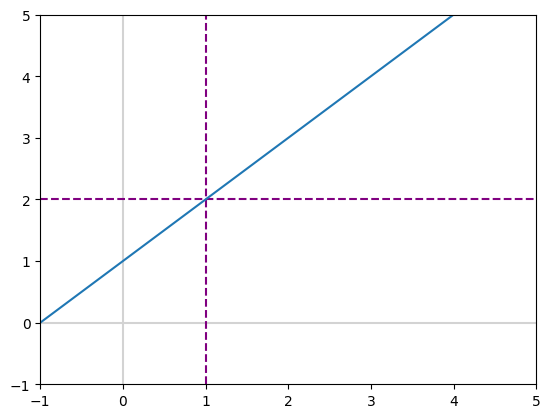

In [112]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.axvline(x=1, color='purple', linestyle='--')
plt.axhline(y=2, color='purple', linestyle='--')
_ = ax.plot(x,y)

We can solve this using mathematic methods too:

$$
\lim_{x \to 1} \frac{x^2 - 1}{x - 1}.
$$

1. First notice that directly substituting $x = 1$ gives
   $$\frac{1^2 - 1}{1 - 1} = \frac{0}{0},$$
   which is an indeterminate form.

2. Factor the numerator using the difference of squares:
   $$x^2 - 1 = (x - 1)(x + 1).$$

3. Substitute this factorization into the expression:
   $$
   \frac{x^2 - 1}{x - 1} = \frac{(x - 1)(x + 1)}{x - 1}.
   $$

4. For $x \neq 1$, we can cancel the common factor $(x - 1)$:
   $$
   \frac{(x - 1)(x + 1)}{x - 1} = x + 1.
   $$

5. Now the limit becomes
   $$
   \lim_{x \to 1} (x + 1) = 1 + 1 = 2.
   $$

**Answer:**
$$
\lim_{x \to 1} \frac{x^2 - 1}{x - 1} = 2.
$$

Now let's pay attention to this:

$$\lim_{x \to 0} \frac{\text{sin } x}{x}$$

In [113]:
def sin_fxn(my_x):
    my_y = np.sin(my_x)/my_x
    return my_y

In [114]:
# Uncommenting the following line results in a 'division by zero' error:
# y = sin_fxn(0)

In [115]:
sin_fxn(0.1)

0.9983341664682815

In [116]:
sin_fxn(0.001)

0.9999998333333416

In [117]:
sin_fxn(-0.1)

0.9983341664682815

In [118]:
sin_fxn(-0.001)

0.9999998333333416

In [119]:
y = sin_fxn(x)

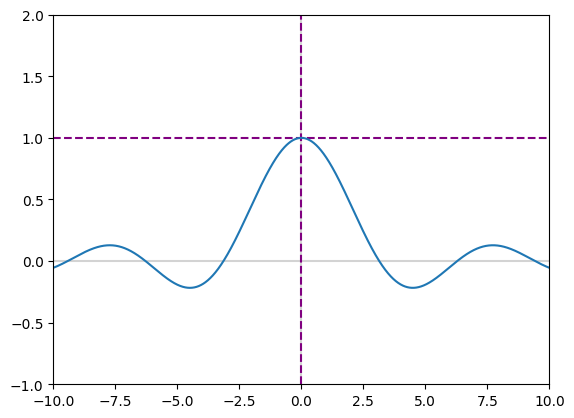

In [120]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-1, 2)
plt.axvline(x=0, color='purple', linestyle='--')
plt.axhline(y=1, color='purple', linestyle='--')
_ = ax.plot(x,y)

**Return to slides here.**

$$ \lim_{x \to \infty} \frac{25}{x} $$

In [121]:
def inf_fxn(my_x):
    my_y = 25/my_x
    return my_y

In [122]:
inf_fxn(1e3) # 1000

0.025

In [123]:
inf_fxn(1e6) # 1 million

2.5e-05

In [124]:
y = inf_fxn(x)

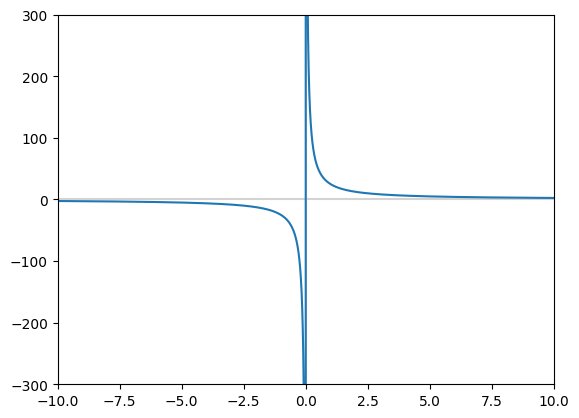

In [125]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-300, 300)
_ = ax.plot(x, y)

In [126]:
left_x = x[x<0]
right_x = x[x>0]

In [127]:
left_y = inf_fxn(left_x)
right_y = inf_fxn(right_x)

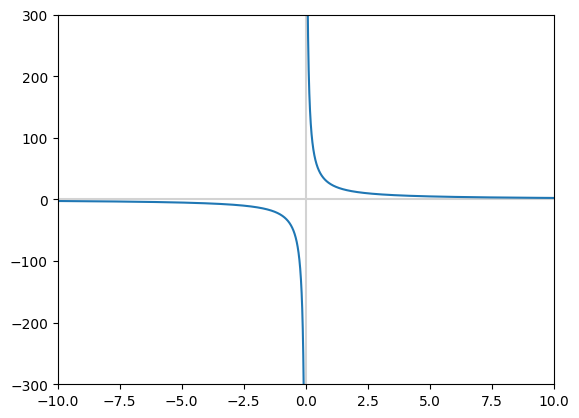

In [128]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.xlim(-10, 10)
plt.ylim(-300, 300)
ax.plot(left_x, left_y, c='C0')
_ = ax.plot(right_x, right_y, c='C0')

**Exercises:**

Evaluate the limits below using techniques from the slides or above.

1. $$ \lim_{x \to 0} \frac{x^2-1}{x-1} $$
2. $$ \lim_{x \to -5} \frac{x^2-25}{x+5} $$
3. $$ \lim_{x \to 4} \frac{x^2 -2x -8}{x-4} $$
4. $$ \lim_{x \to -\infty} \frac{25}{x} $$
5. $$ \lim_{x \to 0} \frac{25}{x} $$

FYI: While not necessary for ML nor for this *ML Foundations* curriculum, the `SymPy` [symbolic mathematics library](https://www.sympy.org/en/index.html) includes a `limits()` method. You can read about applying it to evaluate limits of expressions [here](https://www.geeksforgeeks.org/python-sympy-limit-method/).

**Return to slides here.**

### Computing Derivatives with Differentiation

Using the limit definition of the derivative:

$$
f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}
$$

Let's bring back our ol' buddy $y = x^2 + 2x + 2$:

In [199]:
x = np.linspace(-10, 10, 10000) # start, finish, n points

In [197]:
def f(my_x):
    my_y = my_x**2 + 2*my_x + 2
    return my_y

In [201]:
y = f(x)

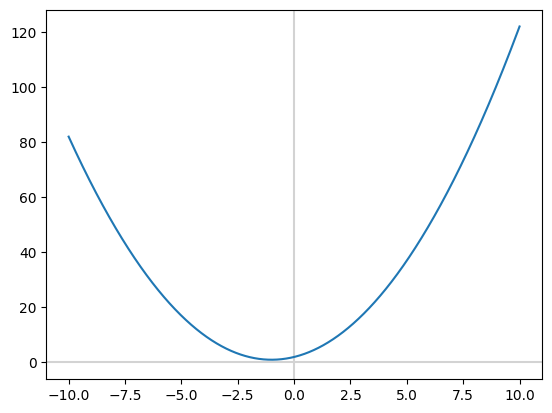

In [202]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
_ = ax.plot(x,y)

Let's identify the slope where, say, $x = 2$.

First, let's determine what $y$ is: 

In [203]:
f(2)

10

Cool. Let's call this point $P$, which is located at (2, 10):

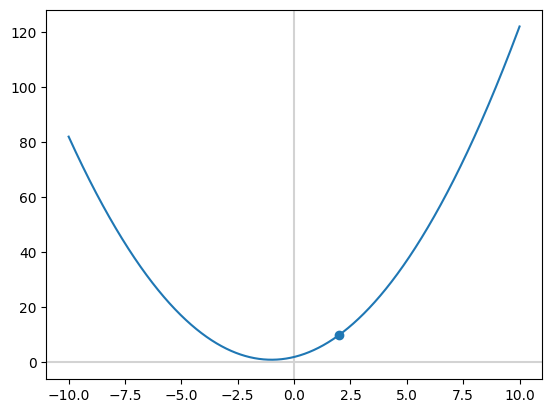

In [204]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10) # new
_ = ax.plot(x,y)

The _delta method_ uses the difference between two points to calculate slope. To illustrate this, let's define another point, $Q$ where, say, $x = 5$.

In [205]:
f(5)

37

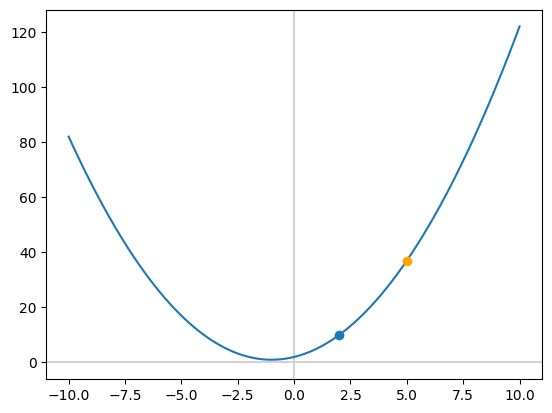

In [206]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(5, 37, c = 'orange', zorder=3) # new
_ = ax.plot(x,y)

To find the slope $m$ between points $P$ and $Q$: 
$$m = \frac{\text{change in }y}{\text{change in }x} = \frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1} = \frac{37-10}{5-2} = \frac{27}{3} = 9$$

In [207]:
m = (37-10)/(5-2)
m

9.0

To plot the line that passes through $P$ and $Q$, we can rearrange the equation of a line $y = mx + b$ to solve for $b$: 
$$b = y - mx$$

In [209]:
b = 37-m*5
b

-8.0

In [210]:
line_y = m*x + b

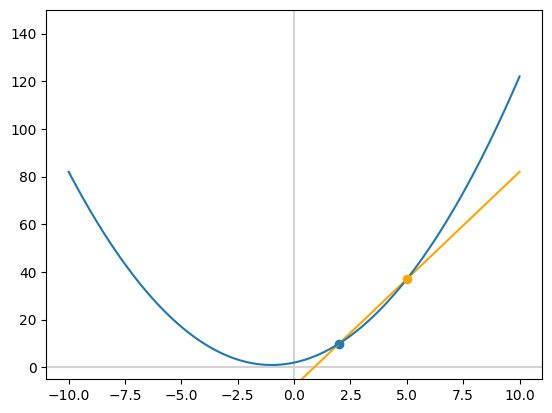

In [219]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(5, 37, c='orange', zorder=3)
plt.ylim(-5, 150) # new
plt.plot(x, line_y, c='orange') # new
#plt.plot(x,y)
_ = ax.plot(x,y)

The closer $Q$ becomes to $P$, the closer the slope $m$ comes to being the true tangent of the point $P$. Let's demonstrate this with another point $Q$ at $x = 2.1$.

Previously, our $\Delta x$ between $Q$ and $P$ was equal to 3. Now it is much smaller: $$\Delta x = x_2 - x_1 = 2.1 - 2 = 0.1 $$

In [140]:
f(2.1)

10.61

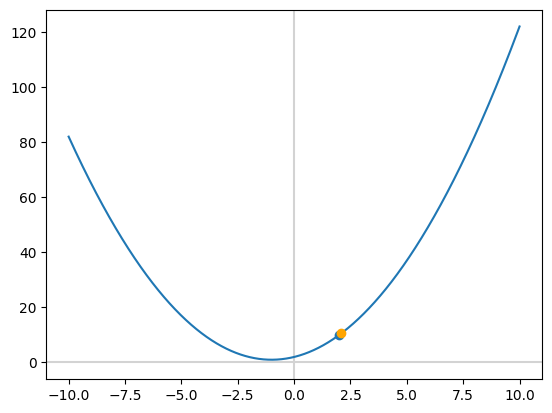

In [141]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(2.1, 10.61, c = 'orange', zorder=3)
_ = ax.plot(x,y)

In [142]:
m = (10.61-10)/(2.1-2)
m

6.099999999999989

In [143]:
b = 10.61-m*2.1
b

-2.199999999999978

In [144]:
line_y = m*x + b

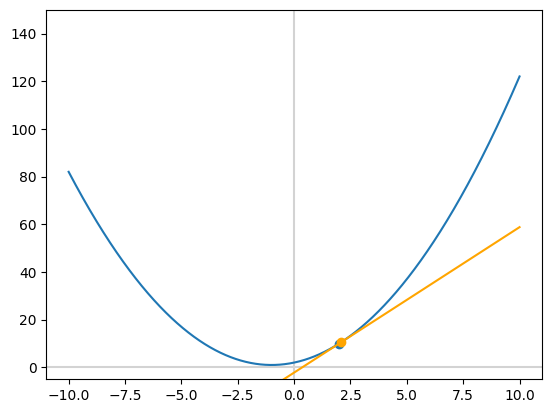

In [145]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(2, 10)
plt.scatter(2.1, 10.61, c='orange', zorder=3)
plt.ylim(-5, 150)
plt.plot(x, line_y, c='orange', zorder=3)
_ = ax.plot(x,y)

The closer $Q$ becomes to $P$ (i.e., $\Delta x$ approaches 0), the clearer it becomes that the slope $m$ at point $P$ = (2, 10) is equal to 6.

Let's make $\Delta x$ extremely small, 0.000001, to illustrate this:

In [146]:
delta_x = 0.000001
delta_x

1e-06

In [147]:
x1 = 2
y1 = 10

Rearranging $\Delta x = x_2 - x_1$, we can calculate $x_2$ for our point $Q$, which is now extremely close to $P$: 
$$x_2 = x_1 + \Delta x$$

In [148]:
x2 = x1 + delta_x
x2

2.000001

$y_2$ for our point $Q$ can be obtained with the usual function $f(x)$: 
$$y_2 = f(x_2)$$

In [149]:
y2 = f(x2)
y2

10.000006000001001

To find the slope $m$, we continue to use $$m = \frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$

In [150]:
m = (y2 - y1)/(x2 - x1)
m

6.000001000088901

Boom! Using the delta method, we've shown that at point $P$, the slope of the curve is 6. 

**Exercise**: Using the delta method, find the slope of the tangent where $x = -1$.

**Spoiler alert! The solution's below.**

In [151]:
x1 = -1

In [152]:
y1 = f(x1)
y1

1

Point $P$ is located at (-1, 1)

In [153]:
delta_x

1e-06

In [154]:
x2 = x1 + delta_x
x2

-0.999999

In [155]:
y2 = f(x2)
y2

1.000000000001

Quick aside: Pertinent to defining differentiation as an equation, an alternative way to calculate $y_2$ is $f(x + \Delta x)$

In [156]:
y2 = f(x1 + delta_x)
y2

1.000000000001

Point $Q$ is at (-0.999999, 1.000000000001), extremely close to $P$.

In [157]:
m = (y2-y1)/(x2-x1)
m

1.0000889005535828e-06

Therefore, as $x_2$ becomes infinitely close to $x_1$, it becomes clear that the slope $m$ at $x_1 = -1$ is equal to zero. Let's plot it out: 

In [158]:
b = y2-m*x2
b

1.0000010000889006

In [159]:
line_y = m*x + b

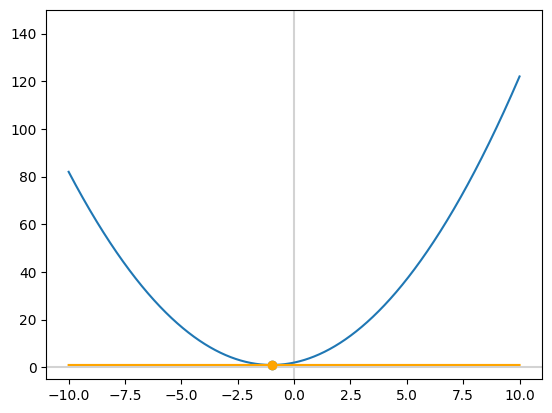

In [160]:
fig, ax = plt.subplots()
plt.axvline(x=0, color='lightgray')
plt.axhline(y=0, color='lightgray')
plt.scatter(x1, y1)
plt.scatter(x2, y2, c='orange', zorder=3)
plt.ylim(-5, 150)
plt.plot(x, line_y, c='orange', zorder=3)
_ = ax.plot(x,y)

As $Q$ becomes infinitely close to $P$:
* $x_2$ - $x_1$ approaches 0
* In other words, $\Delta x$ approaches 0
* This can be denoted as $\Delta x \to 0$

Using the delta method, we've derived the definition of differentiation from first principles. The derivative of $y$ (denoted $dy$) with respect to $x$ (denoted $dx$) can be represented as: 
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{\Delta y}{\Delta x}$$

Expanding $\Delta y$ out to $y_2 - y_1$: 
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{y_2 - y_1}{\Delta x}$$

Finally, replacing $y_1$ with $f(x)$ and replacing $y_2$ with $f(x + \Delta x)$, we obtain a common representation of differentiation:
$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

Let's observe the differentiation equation in action: 

In [161]:
def diff_demo(my_f, my_x, my_delta):
    return (my_f(my_x + my_delta) - my_f(my_x)) / my_delta

In [162]:
deltas = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001]

In [163]:
for delta in deltas:
    print(diff_demo(f, 2, delta))

7.0
6.099999999999994
6.009999999999849
6.000999999999479
6.000100000012054
6.000009999951316
6.000001000927568


In [164]:
for delta in deltas:
    print(diff_demo(f, -1, delta))

1.0
0.10000000000000009
0.009999999999998899
0.001000000000139778
9.99999993922529e-05
1.000000082740371e-05
1.000088900582341e-06


### Derivative Notation

There are three common ways to write the derivative of $y = f(x)$:

| Notation | Form | Notes |
|---|---|---|
| Leibniz | $\dfrac{dy}{dx}$ | Preferred — explicit about *which* variables change |
| Lagrange (prime) | $f'(x)$ | Compact, good for function notation |
| Newton (dot) | $\dot{y}$ | Common in physics for time derivatives |

**We'll use $\dfrac{dy}{dx}$ going forward.**

### Derivative Rules

**Constant Rule** — the derivative of a constant is zero:
$$\frac{d}{dx}[c] = 0$$

**Power Rule** — bring down the exponent, reduce it by 1:
$$\frac{d}{dx}[x^n] = nx^{n-1}$$

**Constant Multiple Rule** — constants factor out:
$$\frac{d}{dx}[c \cdot f(x)] = c \cdot \frac{dy}{dx}$$

**Sum Rule** — differentiate term by term:
$$\frac{d}{dx}[f(x) + g(x)] = \frac{df}{dx} + \frac{dg}{dx}$$

**Product Rule** — for a product of two functions:
$$\frac{d}{dx}[f \cdot g] = f'g + fg'$$

**Quotient Rule** — for a ratio of two functions:
$$\frac{d}{dx}\!\left[\frac{f}{g}\right] = \frac{f'g - fg'}{g^2}$$

**Chain Rule** — for a composite function $f(g(x))$:
$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

It has many ML applications:
 - Gradient descent
 - Critical for backpropagation algorithm which is related to gradient descent when we have deep neural networks. It allows us to chain together all the layers of the neural network and apply gradient descent to the entire thing.

**Power Rule on a Function (Chain Rule applied)**:
$$\frac{d}{dx}[g(x)^n] = n \cdot g(x)^{n-1} \cdot g'(x)$$

#### Product Rule — Example

Find $\dfrac{dy}{dx}$ where $y = x^2 \cdot (x + 3)$.

Let $f = x^2$ and $g = x + 3$, so:

$$f' = 2x \qquad g' = 1$$

Applying $\dfrac{d}{dx}[f \cdot g] = f'g + fg'$:

$$\frac{dy}{dx} = 2x(x + 3) + x^2(1) = 2x^2 + 6x + x^2 = 3x^2 + 6x$$

## Segment 3: Automatic Differentiation

This techniques is applied by ML machines on a massive scales. It is called:
 - Autodiff
 - Autograd or 
 - Computational diff
 - Reverse mode diff
 - Algorithmic diff

It is distinct from classical methods:
 - Numerical diff (delta method etc introduces rounding errors)
 - Symbolic diff (algebraic rules which is computationally inefficient for complex real time functions)

Relative to classical methods, it better handles:
 - Functions with many inputs (common in ML)
 - Higher order derivatives

It works by:
 - Application of chain rule (typically partial derivatives) to a sequence (forward pass) of arithmetic operations
 $$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$
 - Chain rule by hand begins at innermost nested function, autodiff proceeds from outermost function to inward (that is why it is called reverse mode diff).
 - Autodiff is very computationally efficient.

**TensorFlow** and **PyTorch** are the two most popular automatic differentiation libraries. 

Let's use them to calculate $dy/dx$ at $x = 5$ where: 

$$y = x^2$$

$$ \frac{dy}{dx} = 2x = 2(5) = 10 $$

### Autodiff with PyTorch

In [220]:
import torch

In [ ]:
x = torch.tensor(5.0) # Make 5 a scaler tensor of float type for computation 

In [167]:
x

tensor(5.)

`x.requires_grad_()` tells PyTorch: *"start tracking every operation done on this tensor"*. It can be 1000s of functions in the chain that uses x. When we later call `.backward()`, PyTorch replays those tracked operations in reverse (using the chain rule) to compute $\dfrac{dy}{dx}$ automatically. Without this flag, no gradient is computed.

In [223]:
x.requires_grad_() # It says to track the gradient. Contagiously track gradients through forward pass. Here it is needed for getting the derivative

tensor(5., requires_grad=True)

In [226]:
y = x**2

In [227]:
y.backward() # uses autodiff which tracks all the way back through whatever tensors involved in creating the y

In [229]:
x.grad # Basically we ask for x involvment in creating y. This is the derivative of y with respect to x, evaluated at x=5.0, which should be 2*x = 10.0

tensor(10.)

### Autodiff with TensorFlow

In [230]:
import tensorflow as tf

In [231]:
x = tf.Variable(5.0)

In [232]:
with tf.GradientTape() as t:
    t.watch(x) # track forward pass
    y = x**2

In [233]:
t.gradient(y, x) # use autodiff

<tf.Tensor: shape=(), dtype=float32, numpy=10.0>

As usual, PyTorch feels more intuitive and pythonic than TensorFlow. See the standalone [*Regression in PyTorch*](regression-in-pytorch.ipynb) notebook for an example of autodiff paired with gradient descent in order to fit a simple regression line.

## Application of Differentiation in ML

### Fitting a Line with ML

The line equation $\hat{y} = mx + b$ can be represented as a **directed acyclic graph (DAG)**:

- **Nodes** — inputs, parameters, operations, or outputs
- **Directed edges (arrows)** — tensors (data flowing between nodes)

During **training**, we adjust $m$ and $b$ by computing $\dfrac{d\hat{y}}{dm}$ and $\dfrac{d\hat{y}}{db}$ via autodiff and applying gradient descent to minimise the cost.

<svg width="680" height="330" xmlns="http://www.w3.org/2000/svg" font-family="Arial,sans-serif" font-size="13">
  <defs>
    <marker id="arr" markerWidth="10" markerHeight="7" refX="9" refY="3.5" orient="auto">
      <polygon points="0 0,10 3.5,0 7" fill="#555"/>
    </marker>
  </defs>

  <!-- Edges (drawn first, under nodes) -->
  <line x1="148" y1="76"  x2="218" y2="130" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="148" y1="196" x2="218" y2="154" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="312" y1="142" x2="397" y2="186" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="350" y1="275" x2="408" y2="212" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>
  <line x1="480" y1="199" x2="512" y2="199" stroke="#555" stroke-width="1.5" marker-end="url(#arr)"/>

  <!-- x (input) -->
  <ellipse cx="85" cy="76" rx="62" ry="24" fill="#d4e6f1" stroke="#2980b9" stroke-width="1.5"/>
  <text x="85" y="81" text-anchor="middle">x  (input)</text>

  <!-- m (slope) -->
  <ellipse cx="85" cy="196" rx="62" ry="24" fill="#d5f5e3" stroke="#27ae60" stroke-width="1.5"/>
  <text x="85" y="201" text-anchor="middle">m  (slope)</text>

  <!-- × multiply -->
  <rect x="220" y="122" width="92" height="38" rx="6" fill="#fdebd0" stroke="#e67e22" stroke-width="1.5"/>
  <text x="266" y="146" text-anchor="middle">× (multiply)</text>

  <!-- b (intercept) -->
  <ellipse cx="350" cy="292" rx="76" ry="24" fill="#d5f5e3" stroke="#27ae60" stroke-width="1.5"/>
  <text x="350" y="297" text-anchor="middle">b  (intercept)</text>

  <!-- + add -->
  <rect x="398" y="179" width="82" height="38" rx="6" fill="#fdebd0" stroke="#e67e22" stroke-width="1.5"/>
  <text x="439" y="203" text-anchor="middle">+ (add)</text>

  <!-- ŷ (output) -->
  <ellipse cx="578" cy="198" rx="66" ry="24" fill="#f9ebea" stroke="#c0392b" stroke-width="1.5"/>
  <text x="578" y="203" text-anchor="middle">ŷ  (output)</text>
</svg>